# Consultas Analíticas: Customer Journey - Paigo
**Autor:** Franco Robotti  
**Objetivo:** Responder las preguntas de negocio sobre satisfacción y comportamiento del journey, partiendo de los datos ya auditados en `01_calidad_datos`. Cada consulta cierra con sus **Hallazgos Clave** y una visualización.

> Se trabaja sobre `../data/clean/` (tablas limpias con flags de trazabilidad: `producto_valido`, `fecha_inconsistente`). Las métricas mensuales usan la fecha del evento, que es válida; el flag de cronología solo afecta a métricas de antigüedad relativa, que aquí no se calculan.

## 1. Importación y carga

In [16]:
import os
import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["axes.titleweight"] = "bold"
PALETA = "viridis"

CLEAN = "../data/clean"
df_clientes  = pd.read_excel(f"{CLEAN}/clientes_limpio.xlsx")
df_productos = pd.read_excel(f"{CLEAN}/productos_limpio.xlsx")
df_reviews   = pd.read_excel(f"{CLEAN}/reviews_limpio.xlsx")
df_bot       = pd.read_excel(f"{CLEAN}/bot_chats_limpio.xlsx")

df_reviews["fecha_review"] = pd.to_datetime(df_reviews["fecha_review"])
df_bot["fecha_inicio"]     = pd.to_datetime(df_bot["fecha_inicio"])

print("Tablas cargadas:",
      {k: v.shape for k, v in
       {"clientes": df_clientes, "productos": df_productos,
        "reviews": df_reviews, "bot": df_bot}.items()})

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(exist_ok=True)

def guardar(nombre):
    """Guarda la figura actual en FIG_DIR con buena resolución."""
    plt.savefig(FIG_DIR / f"{nombre}.png", dpi=200, bbox_inches="tight")

Tablas cargadas: {'clientes': (1500, 7), 'productos': (5, 8), 'reviews': (2200, 13), 'bot': (3000, 13)}


## Consulta 1 — Rating promedio por canal de adquisición
*¿El canal por el que llega el cliente se relaciona con la satisfacción que expresa en las reviews?*

In [17]:
rating_por_canal = duckdb.query('''
SELECT 
    c.canal_adquisicion,
    ROUND(AVG(r.rating), 2) AS rating_promedio,
    COUNT(*) AS n_reviews
FROM df_reviews r
JOIN df_clientes c ON r.id_cliente = c.id_cliente
GROUP BY c.canal_adquisicion
ORDER BY rating_promedio DESC
''').df()
rating_por_canal

,canal_adquisicion,rating_promedio,n_reviews
0,Orgánico,3.55,566
1,Alianza Comercial,3.54,204
2,Paid Social,3.51,677
3,App Store,3.51,353
4,Referido,3.37,400


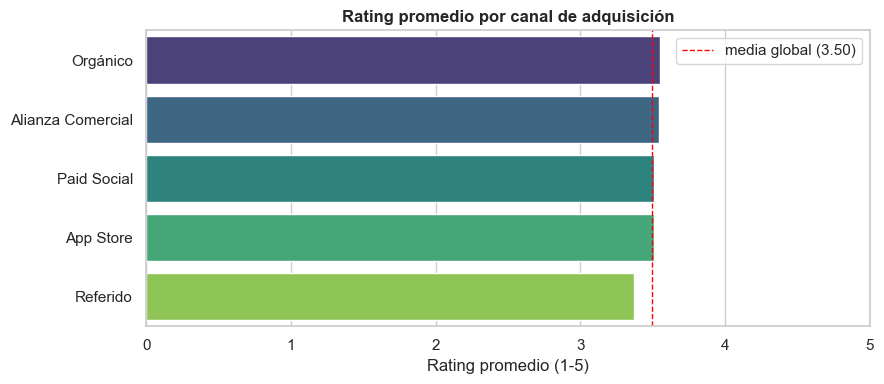

In [18]:
plt.figure(figsize=(9, 4))
sns.barplot(data=rating_por_canal, x="rating_promedio", y="canal_adquisicion",
            hue="canal_adquisicion", palette=PALETA, legend=False)
plt.axvline(df_reviews["rating"].mean(), color="red", linestyle="--", linewidth=1,
            label=f"media global ({df_reviews['rating'].mean():.2f})")
plt.title("Rating promedio por canal de adquisición")
plt.xlabel("Rating promedio (1-5)"); plt.ylabel(""); plt.xlim(0, 5)
plt.legend()
plt.tight_layout(); 
guardar("02_rating_por_canal")
plt.show()

**Hallazgos Clave:**
* Las diferencias son **mínimas**: todos los canales caen entre **3.37 y 3.55** sobre 5. El canal de adquisición **no explica** de forma relevante el rating.
* El más bajo es **Referido (3.37)** y el más alto **Orgánico (3.55)**, pero la brecha (0.18) es despreciable frente al desvío dentro de cada canal.

## Consulta 2 — Tasa de escalado a humano por intent y canal
*¿Qué tipos de consulta y qué canales del bot derivan más a un agente humano?*

In [19]:
escalado_intent_canal = duckdb.query('''
SELECT 
    b.intent_primario,
    b.canal,
    COUNT(*) AS total_chats,
    ROUND(100.0 * SUM(CASE WHEN b.escalado_humano = 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS tasa_escalado_pct
FROM df_bot b
GROUP BY b.intent_primario, b.canal
ORDER BY tasa_escalado_pct DESC
''').df()
escalado_intent_canal.head(10)

,intent_primario,canal,total_chats,tasa_escalado_pct
0,baja_producto,SMS,2,100.0
1,derivacion_humano,SMS,10,40.0
2,reclamo_cobro,App,102,33.3
3,consulta_tasa,Web,15,33.3
4,onboarding_dudas,App,103,33.0
5,consulta_tasa,App,52,30.8
6,consulta_saldo,SMS,33,30.3
7,consulta_tasa,WhatsApp,110,30.0
8,onboarding_dudas,Web,70,30.0
9,estado_solicitud,WhatsApp,187,28.9


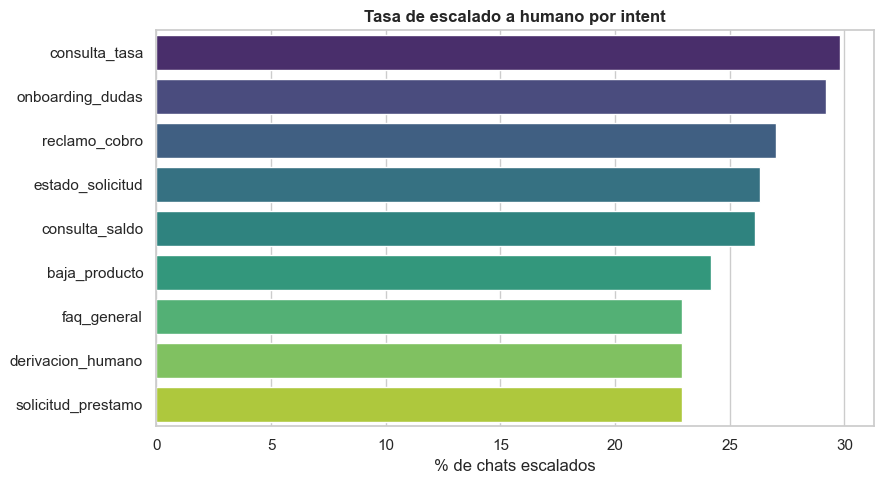

In [20]:
escalado_intent = duckdb.query('''
SELECT intent_primario,
       COUNT(*) AS n,
       ROUND(100.0 * SUM(CASE WHEN escalado_humano = 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS tasa
FROM df_bot GROUP BY 1 ORDER BY tasa DESC
''').df()

plt.figure(figsize=(9, 5))
sns.barplot(data=escalado_intent, x="tasa", y="intent_primario",
            hue="intent_primario", palette=PALETA, legend=False)
plt.title("Tasa de escalado a humano por intent")
plt.xlabel("% de chats escalados"); plt.ylabel("")
plt.tight_layout(); 
guardar("02_tasa_escalado_por_intent")
plt.show()

**Hallazgos Clave:**
* La tasa de escalado es **bastante pareja** (22.9%–29.8%). Los intents que más derivan son **`consulta_tasa` (29.8%)** y **`onboarding_dudas` (29.2%)**; los que menos, `faq_general` y `solicitud_prestamo` (22.9%).
* **Señal de calidad (heredada del notebook 01):** el campo `escalado_humano` es **incoherente** con `resolucion`. Por ejemplo, el intent `derivacion_humano` escala solo 22.9% (debería ser casi total) y hay chats "Resuelto bot" marcados como escalados. Por eso esta tasa debe leerse como un indicador **aproximado**: mide el flag tal cual está, no necesariamente la intervención humana real.
* **Acción:** priorizar contenido de autoservicio para `consulta_tasa` y `onboarding_dudas`, y **sanear el registro de `escalado_humano`** antes de usarlo como KPI.

## Consulta 3 — Evolución mensual del CSAT y el rating
*¿Cómo evolucionan en el tiempo la satisfacción del bot (CSAT) y la de las reviews (rating)?*

**Aclaración metodológica importante:** la consigna pide "por versión de app", pero `version_app` **solo existe en `reviews_stores`**; `bot_chats` no la tiene. Por lo tanto, el **CSAT no puede desagregarse por versión**: se calcula a nivel mensual. El rating sí se abre por versión (ver tabla complementaria). Además, se **deduplica** una review por cliente y mes (la última) para no sobreponderar usuarios que dejan varias reviews.

In [21]:
evolucion = duckdb.query('''
WITH reviews_dedup AS (
    SELECT 
        strftime(fecha_review, '%Y-%m') AS mes,
        id_cliente, rating,
        ROW_NUMBER() OVER (
            PARTITION BY id_cliente, strftime(fecha_review, '%Y-%m')
            ORDER BY fecha_review DESC) AS rn
    FROM df_reviews
),
rating_mes AS (
    SELECT mes, ROUND(AVG(rating), 2) AS rating_promedio,
           COUNT(*) AS n_reviews
    FROM reviews_dedup WHERE rn = 1 GROUP BY mes
),
csat_mes AS (
    SELECT strftime(fecha_inicio, '%Y-%m') AS mes,
           ROUND(AVG(csat_score), 2) AS csat_promedio,
           COUNT(*) AS n_chats
    FROM df_bot GROUP BY mes
)
SELECT r.mes, r.rating_promedio, b.csat_promedio, r.n_reviews, b.n_chats
FROM rating_mes r
LEFT JOIN csat_mes b ON r.mes = b.mes
ORDER BY r.mes
''').df()
print("Meses:", len(evolucion))
evolucion.head()

Meses: 27


,mes,rating_promedio,csat_promedio,n_reviews,n_chats
0,2023-01,3.83,2.83,78,116
1,2023-02,3.67,2.74,73,96
2,2023-03,3.52,2.64,93,126
3,2023-04,3.52,2.86,82,108
4,2023-05,3.43,2.74,75,119


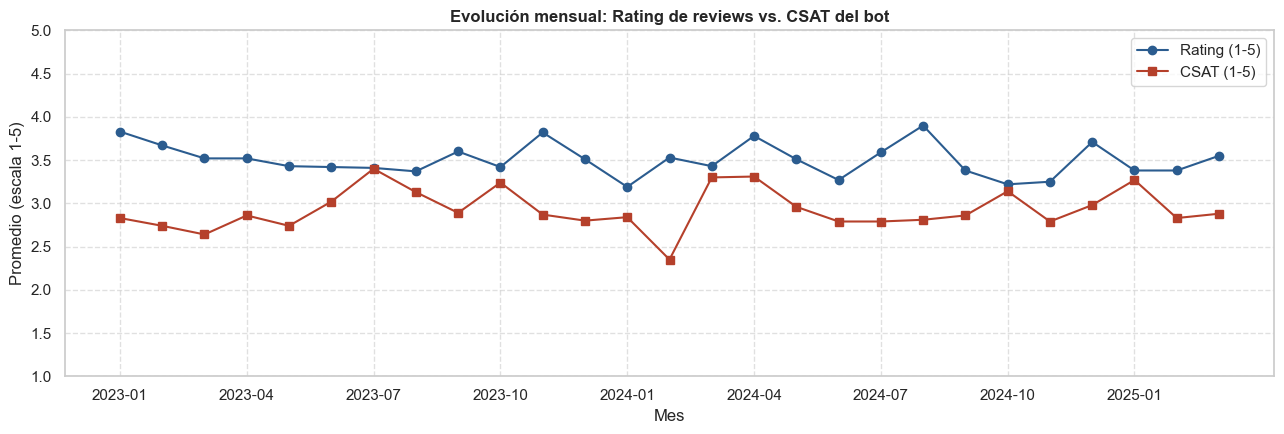

In [22]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(evolucion["mes"], evolucion["rating_promedio"], marker="o", label="Rating (1-5)", color="#2b5c8f")
ax.plot(evolucion["mes"], evolucion["csat_promedio"], marker="s", label="CSAT (1-5)", color="#b5402b")
ax.set_title("Evolución mensual: Rating de reviews vs. CSAT del bot")
ax.set_xlabel("Mes"); ax.set_ylabel("Promedio (escala 1-5)")
ax.set_xticks(evolucion["mes"][::3]); ax.set_ylim(1, 5)
ax.legend(); ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout(); 
guardar("02_evolucion_rating_csat")
plt.show()

In [23]:
# Tabla complementaria: rating por versión de app (lo que sí se puede desagregar)
rating_version = duckdb.query('''
SELECT version_app,
       ROUND(AVG(rating), 2) AS rating_promedio,
       COUNT(*) AS n_reviews
FROM df_reviews GROUP BY version_app ORDER BY version_app
''').df()
rating_version

,version_app,rating_promedio,n_reviews
0,2.1.0,3.44,372
1,2.2.1,3.58,387
2,2.3.0,3.61,333
3,2.4.2,3.47,355
4,3.0.0,3.44,386
5,3.1.1,3.47,367


**Hallazgos Clave:**
* El **rating** se mantiene en torno a **3.4–3.8** y el **CSAT** sensiblemente más bajo, en **2.6–3.0**. Es decir, la experiencia con el **bot** se percibe peor que la de la app en general.
* Ambas series son **estables**, sin una tendencia marcada de mejora ni deterioro en el período.
* **CSAT bajo y persistente** es la señal más accionable de esta vista: el asistente conversacional arrastra una satisfacción mediocre mes a mes.
* La tabla por versión muestra diferencias pequeñas de rating entre versiones; no hay una versión que claramente dispare la insatisfacción.

## Consulta 4 — Productos con más reviews negativas
*¿Qué productos concentran la insatisfacción? (insumo directo para el dashboard)*

In [24]:
reviews_por_producto = duckdb.query('''
SELECT 
    COALESCE(p.nombre_producto, 'Desconocido (id 6/7/8)') AS producto,
    COUNT(*) AS total_reviews,
    SUM(CASE WHEN r.rating <= 2 THEN 1 ELSE 0 END) AS reviews_negativas,
    ROUND(100.0 * SUM(CASE WHEN r.rating <= 2 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_negativas
FROM df_reviews r
LEFT JOIN df_productos p ON r.id_producto = p.id_producto
GROUP BY 1
ORDER BY pct_negativas DESC
''').df()
reviews_por_producto

,producto,total_reviews,reviews_negativas,pct_negativas
0,BNPL Cuotas 3x,257,97.0,37.7
1,Préstamo Personal Express,295,92.0,31.2
2,BNPL Cuotas 6x,270,81.0,30.0
3,Microcrédito Emprendedor,284,83.0,29.2
4,Desconocido (id 6/7/8),805,232.0,28.8
5,Préstamo Personal Flex,289,69.0,23.9


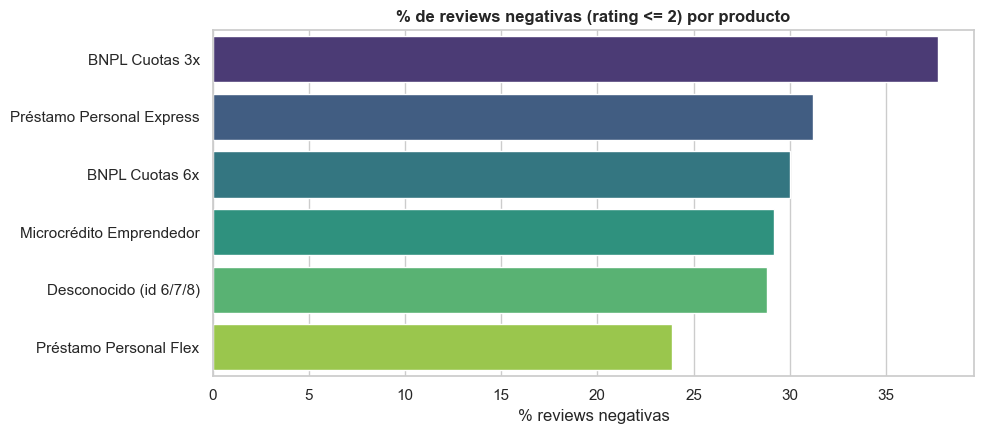

In [25]:
plt.figure(figsize=(10, 4.5))
sns.barplot(data=reviews_por_producto, x="pct_negativas", y="producto",
            hue="producto", palette=PALETA, legend=False)
plt.title("% de reviews negativas (rating <= 2) por producto")
plt.xlabel("% reviews negativas"); plt.ylabel("")
plt.tight_layout(); 
guardar("02_pct_reviews_negativas_por_producto")
plt.show()

**Hallazgos Clave:**
* **`BNPL Cuotas 3x` es el producto más conflictivo: 37.7%** de sus reviews son negativas, bastante por encima del resto.
* Le siguen **`Préstamo Personal Express` (31.2%)** y **`BNPL Cuotas 6x` (30.0%)**. El más sano es **`Préstamo Personal Flex` (23.9%)**.
* La categoría **"Desconocido (id 6/7/8)"** agrupa las **805 reviews con producto inexistente** (detectadas en el notebook 01). Con 28.8% de negativas, no se pueden atribuir a un producto del catálogo → **recuperar esos 3 productos faltantes** es prioritario para no perder visibilidad sobre un tercio de las reviews.
* **Acción:** foco de producto/soporte en la línea **BNPL**, que concentra la peor percepción.

## Consulta 5 — Doble insatisfacción por canal (insight accionable)
*¿Qué canal de adquisición trae clientes que están insatisfechos **en los dos frentes** a la vez — reviews y bot?*

Definimos "doble insatisfacción" como un cliente que dejó **al menos una review ≤ 2** *y* tuvo **al menos un chat con CSAT ≤ 2**. Es la señal de churn más fuerte que permiten los datos.

In [26]:
doble_insatisfaccion = duckdb.query('''
WITH review_mala AS (SELECT DISTINCT id_cliente FROM df_reviews WHERE rating <= 2),
     chat_malo   AS (SELECT DISTINCT id_cliente FROM df_bot WHERE csat_score <= 2)
SELECT 
    c.canal_adquisicion,
    COUNT(DISTINCT c.id_cliente) AS total_clientes,
    COUNT(DISTINCT CASE WHEN rm.id_cliente IS NOT NULL AND cm.id_cliente IS NOT NULL
                        THEN c.id_cliente END) AS clientes_doble_insat,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN rm.id_cliente IS NOT NULL AND cm.id_cliente IS NOT NULL
                        THEN c.id_cliente END) / COUNT(DISTINCT c.id_cliente), 1) AS pct_doble_insat
FROM df_clientes c
LEFT JOIN review_mala rm ON c.id_cliente = rm.id_cliente
LEFT JOIN chat_malo  cm ON c.id_cliente = cm.id_cliente
GROUP BY c.canal_adquisicion
ORDER BY pct_doble_insat DESC
''').df()
doble_insatisfaccion

,canal_adquisicion,total_clientes,clientes_doble_insat,pct_doble_insat
0,Orgánico,385,48,12.5
1,App Store,235,26,11.1
2,Paid Social,456,49,10.7
3,Referido,280,27,9.6
4,Alianza Comercial,144,10,6.9


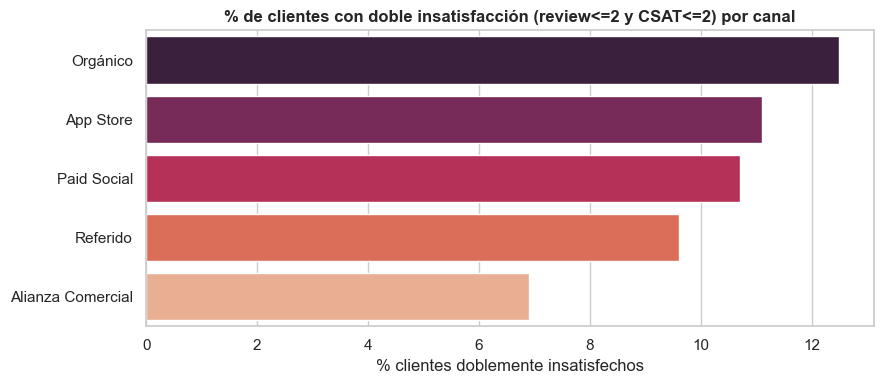

In [27]:
plt.figure(figsize=(9, 4))
sns.barplot(data=doble_insatisfaccion, x="pct_doble_insat", y="canal_adquisicion",
            hue="canal_adquisicion", palette="rocket", legend=False)
plt.title("% de clientes con doble insatisfacción (review<=2 y CSAT<=2) por canal")
plt.xlabel("% clientes doblemente insatisfechos"); plt.ylabel("")
plt.tight_layout(); 
guardar("02_doble_insatisfaccion_por_canal")
plt.show()

**Hallazgos Clave e insight accionable:**
* **`Orgánico` lidera la doble insatisfacción con 12.5%**, seguido de `App Store` (11.1%) y `Paid Social` (10.7%). El más bajo es `Alianza Comercial` (6.9%).
* **El dato contraintuitivo:** `Orgánico` tenía el **mejor** rating promedio (Consulta 1, 3.55) pero a la vez la **mayor** proporción de clientes doblemente insatisfechos. La media lo hacía ver sano; el cruce revela un **segmento crítico oculto** en su cola.
* **Insight para negocio:** los clientes que llegan por `Orgánico` y `Paid Social` (los dos canales de mayor volumen) son los que más concentran insatisfacción severa multi-canal. Son el **target prioritario de una campaña de retención/reactivación** — justamente el tipo de acción del rol (engagement sobre el ciclo de vida).

## Síntesis y recomendaciones

| # | Pregunta | Hallazgo | Acción |
|:-:|:---|:---|:---|
| 1 | Rating por canal | Plano (3.37–3.55); la media oculta la polarización | Analizar extremos, no promedios |
| 2 | Escalado por intent | `consulta_tasa` y `onboarding_dudas` lideran (~29%); flag incoherente | Autoservicio + sanear `escalado_humano` |
| 3 | Evolución CSAT/rating | CSAT bajo y estable (2.6–3.0) < rating (3.4–3.8) | Priorizar mejora del bot |
| 4 | Productos negativos | BNPL Cuotas 3x el peor (37.7%); 805 reviews sin producto | Foco BNPL + recuperar catálogo |
| 5 | Doble insatisfacción | `Orgánico` (12.5%) y `Paid Social` esconden el peor segmento | **Campaña de retención dirigida** |

**Insight accionable principal:** segmentar y dirigir una campaña de reactivación a los clientes con doble insatisfacción de los canales `Orgánico` y `Paid Social`, midiendo el impacto con un A/B test — un caso de uso directo del rol de Customer Engagement.